In [ ]:
import pandas as pd 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 경로를 지정하여 Graphviz를 설치한 경우, 다음과 같이 경로를 설정할 수 있습니다.
from sklearn.tree import export_graphviz
import graphviz

In [2]:
# HPO를 위한 설정
from sklearn.model_selection import train_test_split, GridSearchCV

In [3]:
# XAI를 위한 설정
from sklearn.inspection import PartialDependenceDisplay

In [4]:
# 데이터 로드
wine = load_wine()

In [5]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

In [6]:
# 모형 학습
# 특성과 타겟의 데이터를 분리
X = df.drop('target', axis=1)
y = df['target']    

In [7]:
# 학습 데이터와 테스트 데이터로 분리(80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Hyperparameter Tuning (HPO) 설정 '자동' 변경
# GridSearchCV를 사용하여 최적의 하이퍼파라미터 탐색

param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [2,3,4,5],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
}

In [9]:
# HPO 및 Fitting
clf_grid = DecisionTreeClassifier(random_state=42)

# core
grid_search = GridSearchCV(estimator=clf_grid, param_grid=param_grid, cv=5)
# Fitting
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터와 정확도 출력
print(f"최적의 하이퍼파라미터: {grid_search.best_params_}")
print(f"최적의 정확도: {grid_search.best_score_}")

최적의 하이퍼파라미터: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
최적의 정확도: 0.9224137931034484


In [10]:
best_model = grid_search.best_estimator_

y_pred_grid = best_model.predict(X_test)
accuracy_grid = accuracy_score(y_test, y_pred_grid)

In [11]:
# 최적의 모델로 테스트 데이터 예측 및 평가
print(f"GridSearchCV 설정 정확도: {accuracy_grid:.4f}")

GridSearchCV 설정 정확도: 0.9444


In [13]:
# Feature Importance를 계산
importances = best_model.feature_importances_

In [14]:
importances

array([0.        , 0.        , 0.02134756, 0.        , 0.        ,
       0.        , 0.41901243, 0.        , 0.        , 0.39238767,
       0.        , 0.        , 0.16725234])

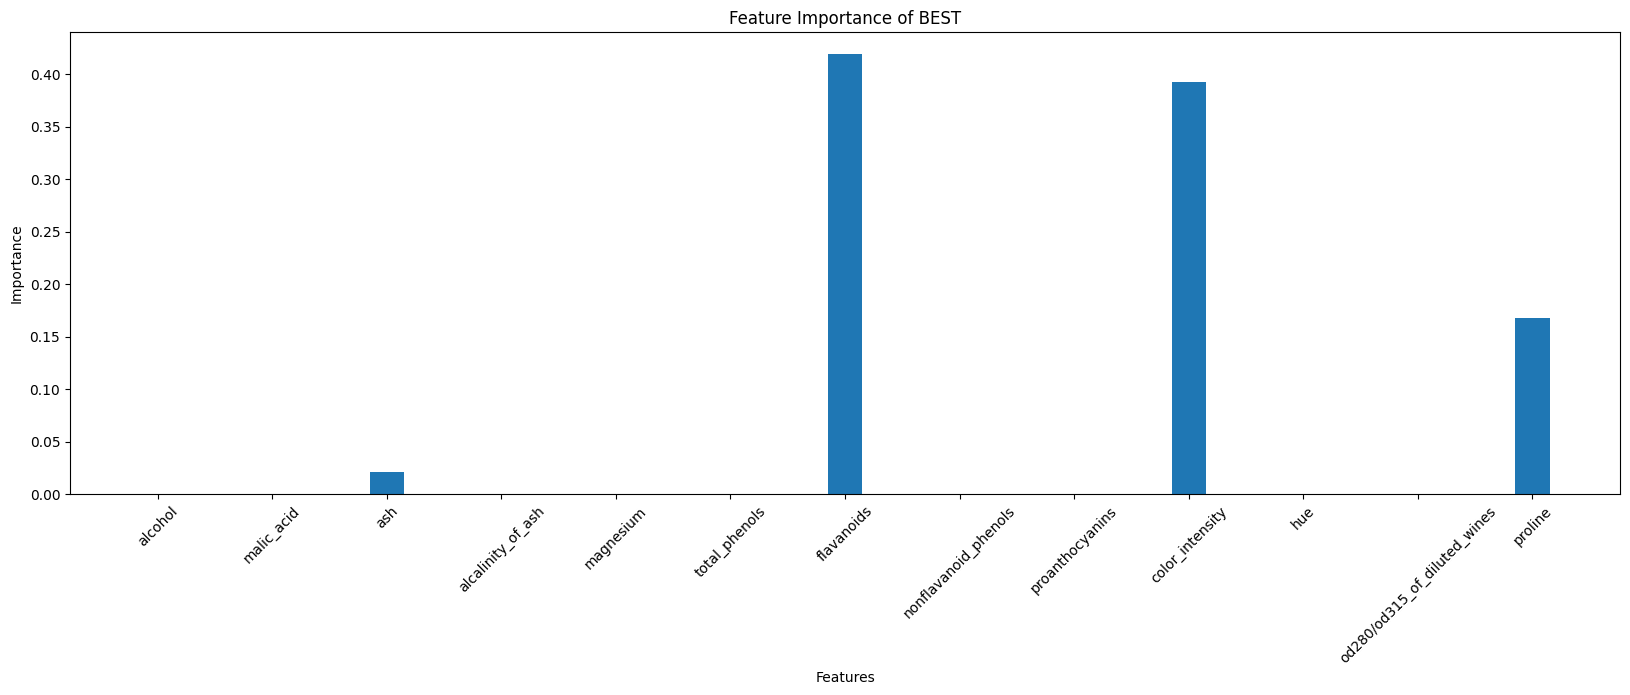

In [ ]:
# BEST의 Feature Importance를 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
# feature importance 시각화
plt.bar(range(len(importances)), importances, width=0.3)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(range(len(importances)), X.columns, rotation = 45)
plt.title('Feature Importance of BEST')
plt.show()

In [17]:
X.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

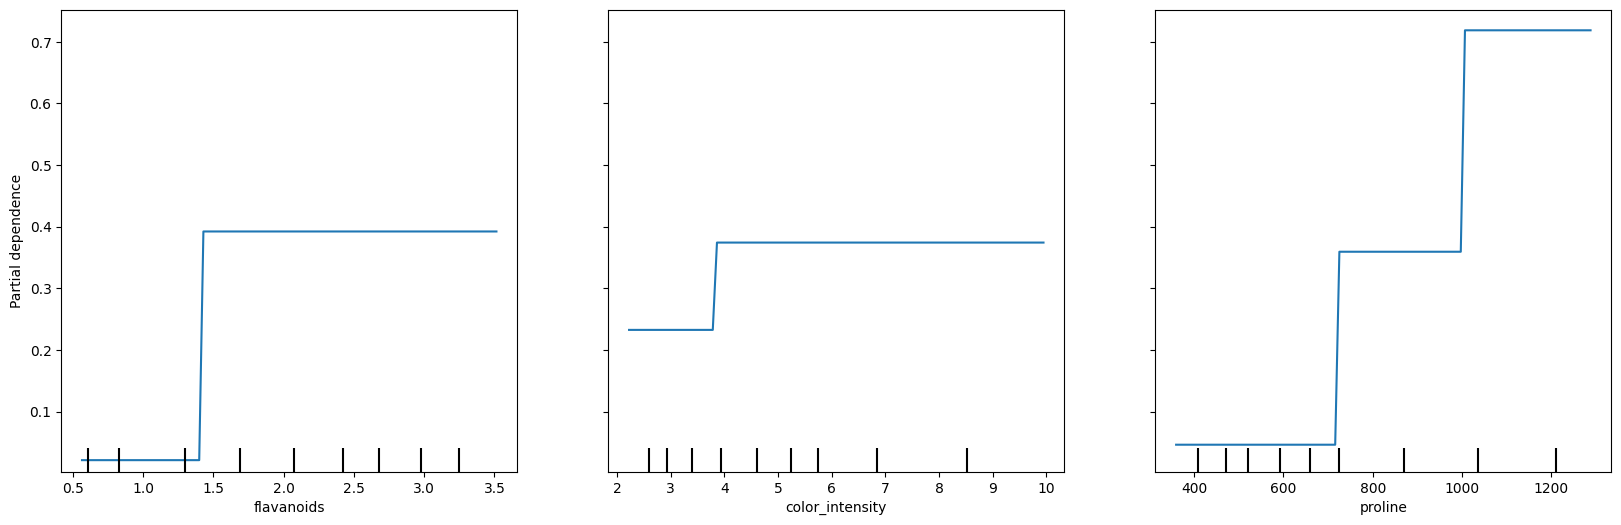

In [18]:
# Partial Dependence Plot (PDP) 시각화
# 시각화할 특성 선택
feature = ['flavanoids','color_intensity','proline']
fig, ax = plt.subplots(figsize=(20, 6))
display = PartialDependenceDisplay.from_estimator(best_model, X_train, features=feature, target = 0, ax=ax)
plt.show()

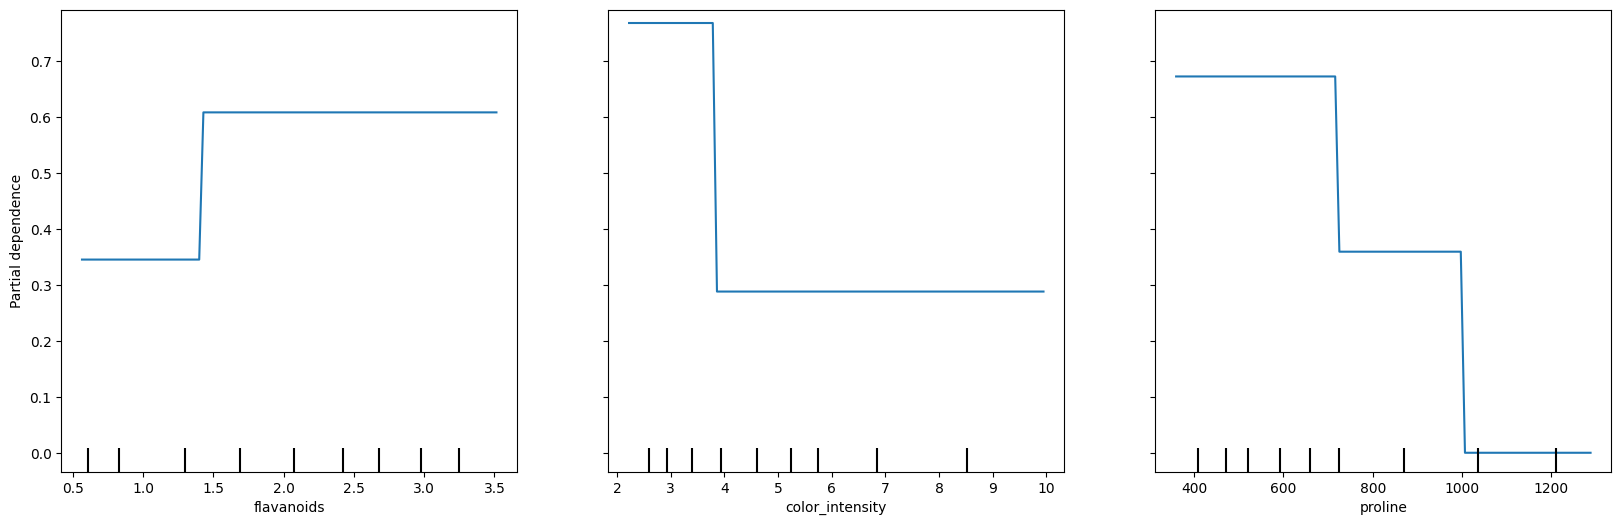

In [20]:
fig, ax = plt.subplots(figsize=(20, 6))
display = PartialDependenceDisplay.from_estimator(best_model, X_train, features=feature, target = 1, ax=ax)
plt.show()

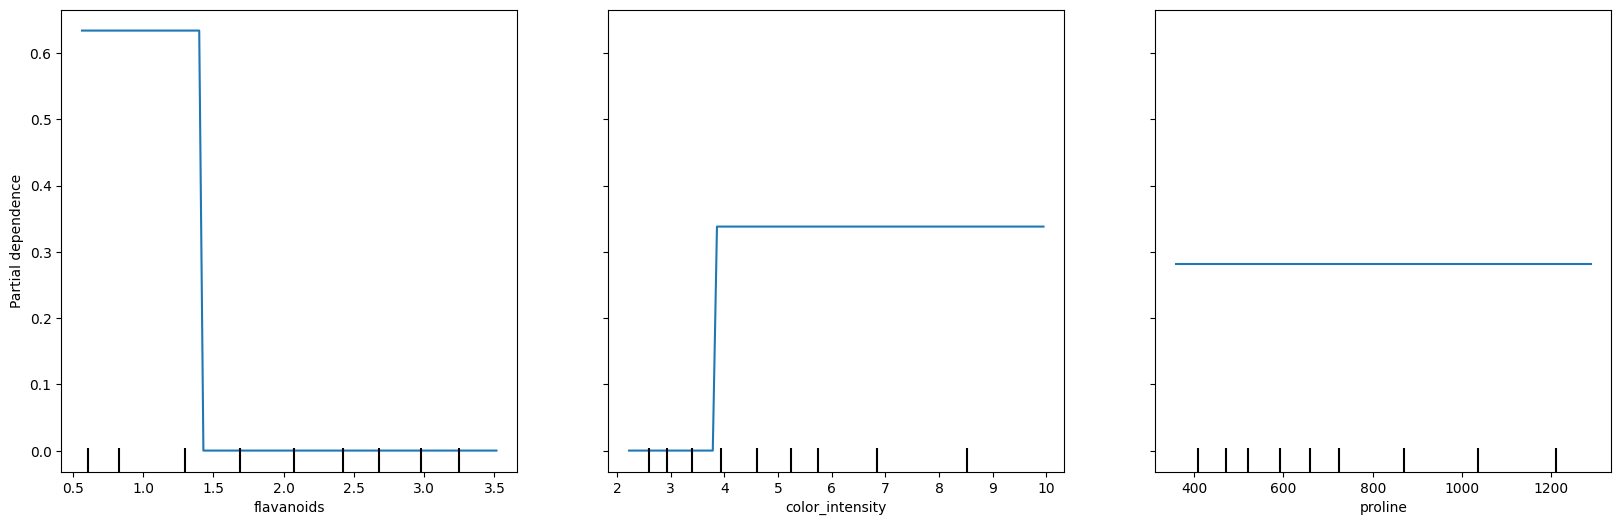

In [21]:
fig, ax = plt.subplots(figsize=(20, 6))
display = PartialDependenceDisplay.from_estimator(best_model, X_train, features=feature, target = 2, ax=ax)
plt.show()